# Example 01 — Radial Arc + SMBH (Einstein-Spiral Analog)

**The canonical AGEL setup, simplified.** A single lens galaxy at z=0.7 produces a radial arc from a source at z=1.5 placed near the radial caustic. A massive black hole at the lens centre adds a `PointMass` perturbation. The combined system probes the inner mass slope γ′ (radial arcs are the sharpest constraint we have — Krywult+2017, Ferrami+2024) **and** the central black hole mass via the same imaging data.

**Prerequisites.** Module 15 (Radial Arcs & Caustic Topology) for the γ′–M_BH physics; Module 13 (TDCOSMO with kinematics) for what eventually breaks the degeneracy.

**This notebook.** Loads the autolens-native mock (chi²-at-truth = 1.03), inspects the data, points at the two Cannon-landed fits (`rarc_direct` PowerLaw+shear and `rarc_with_pointmass` +PointMass), audits both with Module 11's 6-panel walk, and discusses the **headline pedagogical point**: at this S/N and pixel scale, the BH is **not detected** by imaging alone — Δlog_Z = +1.71 in favour of the simpler model is the γ′–M_BH degeneracy in numerical form.

**Time.** ~10 min to read; ~30 s to execute. No Cannon dependency (it reads pulled fit results, graceful when absent).

**The headline finding.** This example exists to demonstrate a **negative result** to students: you cannot detect θ_E_BH ≈ 0.08″ from imaging alone, even with sub-pixel PSFs and chi²/N ≈ 1.0 fits. Module 13 introduces stellar kinematics (σ_v) as the orthogonal probe that breaks the γ′–M_BH degeneracy. Real AGEL UMBHs (θ_E_BH ≈ 0.02″) are well below this floor — joint imaging + kinematics is required.

## 1. The setup

**Mock geometry** (autolens-native via `mocks/generate_mock.py`, chi²-at-truth = 1.029):

| Quantity | Truth |
|---|---|
| z_lens | 0.7 |
| z_source | 1.5 |
| Lens mass — `PowerLaw` | θ_E = 1.0″, slope γ′ = 1.95, ell_comps = (0.10, 0.05) |
| Lens shear — `ExternalShear` | γ₁ = 0.025, γ₂ = −0.015 |
| **Embedded SMBH — `PointMass`** | **θ_E_BH = 0.08″, centred on lens** |
| Lens light — `Sersic` (de Vaucouleurs) | n=4, R_e=0.8″, intensity=1.0 |
| Source — `Sersic` (Sb disc) | n=1.5, R_e=0.18″, intensity=0.5, offset=(0.06, 0.03)″ |
| Imaging | 80×80 px @ 0.05″/px, HST WFC3-IR-like (FWHM 0.12″) |
| Exposure / sky RMS | 1000 s / 0.01 e⁻/s |
| **Companion kinematics dataset** | **σ_v = 278.6 ± 10 km/s, R_eff aperture, isotropic Jeans truth = 280 km/s** |

**Pedagogically-large BH.** θ_E_BH = 0.08″ is ~5× larger than expected for real AGEL ultra-massive black holes (UMBHs, θ_E_BH ≈ 0.02″). The intent is to show the **detection floor** — see if even a 5×-amplified BH is detectable from this imaging data alone.

**Radial arc geometry.** The source at offset (0.06, 0.03)″ from the optical axis sits *just inside* the radial caustic. PowerLaw lenses with γ′ < 2 (sub-isothermal) have a radial caustic at finite radius; sources near it produce a radial arc — the brightest, most elongated arc segment along the optical axis. Radial-arc positions are exquisitely sensitive to γ′ — this is *why* this geometry probes the slope so well.

In [1]:
from pathlib import Path
import json
import autolens as al

REPO = Path('.').resolve()
while not (REPO / 'requirements.txt').exists() and REPO != REPO.parent:
    REPO = REPO.parent
EX = REPO / 'Examples' / 'radial_arc_smbh'
MOCKS = EX / 'mocks'
RESULTS = EX / 'results'

dataset = al.Imaging.from_fits(
    data_path=MOCKS / 'image.fits',
    noise_map_path=MOCKS / 'noise_map.fits',
    psf_path=MOCKS / 'psf.fits',
    pixel_scales=0.05,
)
truths = json.loads((MOCKS / 'truths.json').read_text())
print(f'data shape:           {dataset.shape_native}')
print(f'truth theta_E:        {truths["lens"]["mass"]["einstein_radius"]} arcsec')
print(f'truth gamma\u2032:           {truths["lens"]["mass"]["slope"]}')
print(f'truth theta_E_BH:     {truths["lens"]["smbh"]["einstein_radius"]} arcsec')
print(f'truth sigma_v:        {truths["kinematics"]["sigma_v_obs_kms"]:.2f} km/s (obs);'
      f' {truths["kinematics"]["sigma_v_truth_kms"]:.1f} km/s (Jeans truth)')

data shape:           (80, 80)
truth theta_E:        1.0 arcsec
truth gamma′:           1.95
truth theta_E_BH:     0.08 arcsec
truth sigma_v:        278.58 km/s (obs); 280.0 km/s (Jeans truth)


## 2. Visualise the data

The data shows a near-Einstein ring (the source is close to the tangential caustic). Look closely at the inner edge of the ring — the source's proximity to the **radial caustic** elongates the arc radially; this is the diagnostic feature. The central PSF spike sits on top of the (much fainter) BH-induced extra image, which is **at the noise floor** in pure imaging.

2026-05-15 14:47:23,803 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 4060 image-pixels


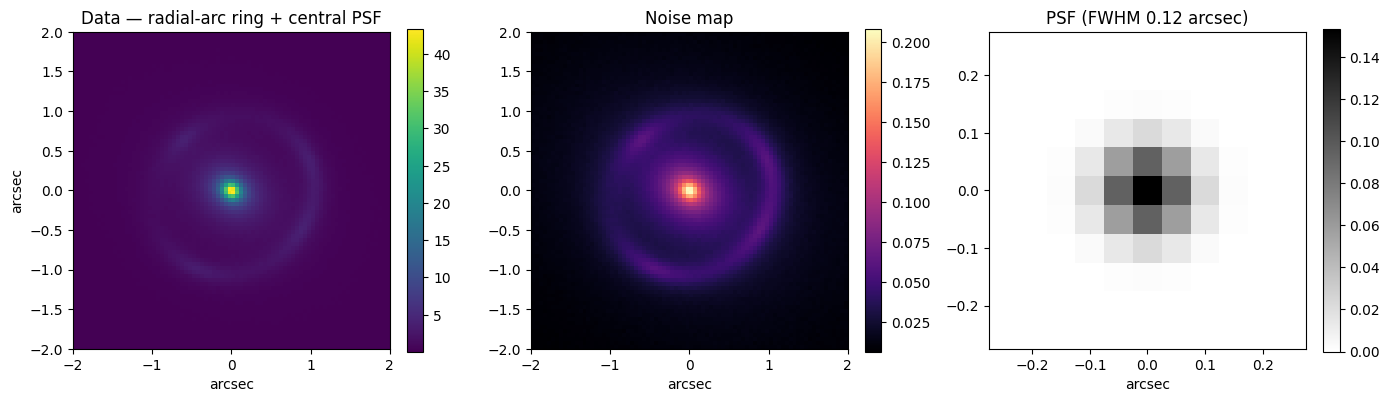

masked pixels: 4060


In [2]:
import matplotlib.pyplot as plt
import numpy as np

mask = al.Mask2D.circular(
    shape_native=dataset.shape_native, pixel_scales=dataset.pixel_scales,
    radius=1.8,
)
masked = dataset.apply_mask(mask=mask)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
extent = [-2.0, 2.0, -2.0, 2.0]
im0 = axes[0].imshow(np.array(dataset.data.native), origin='lower', cmap='viridis', extent=extent)
axes[0].set_title('Data — radial-arc ring + central PSF'); axes[0].set_xlabel('arcsec'); axes[0].set_ylabel('arcsec')
plt.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(np.array(dataset.noise_map.native), origin='lower', cmap='magma', extent=extent)
axes[1].set_title('Noise map'); axes[1].set_xlabel('arcsec')
plt.colorbar(im1, ax=axes[1], fraction=0.046)
psf_arr = np.array(dataset.psf.kernel.native)
half = psf_arr.shape[0] * dataset.pixel_scales[0] / 2
im2 = axes[2].imshow(psf_arr, origin='lower', cmap='gray_r', extent=[-half, half, -half, half])
axes[2].set_title('PSF (FWHM 0.12 arcsec)'); axes[2].set_xlabel('arcsec')
plt.colorbar(im2, ax=axes[2], fraction=0.046)
plt.tight_layout(); plt.show()
print(f'masked pixels: {masked.mask.pixels_in_mask}')

## 3. The two models — direct vs. with PointMass

The driver `fit_example_radial_arc_smbh.py` builds **two parallel rungs** of the same model ladder:

**`--part=direct`** (12 free params): `PowerLaw` lens mass + `ExternalShear` + `Sersic` lens light + `Sersic` source. **No SMBH.** This is the null hypothesis.

**`--part=with_pointmass`** (13 free params): same as `direct` + `al.mp.PointMass(centre=tied_to_bulge, einstein_radius)`. The PointMass `einstein_radius` is the BH parameter — prior `LogUniform(1e-3, 0.5)` arcsec.

**Bayes-factor logic.** If the BH is detectable, `with_pointmass` should win by Δlog_Z ≳ +5 (decisive) or +3 (strong). If Δlog_Z is comparable (|Δ| ≲ 2) the BH parameter is *prior-marginalised* — the data does not constrain it.

**Submission (siag_lab, 32 cores, 4h wall):**
```bash
for PART in direct with_pointmass; do
    sbatch --account=siag_lab --partition=siag --mem=192G --cpus-per-task=32 \
        --time=4:00:00 --job-name=rarc_${PART} \
        --export=ALL,EXAMPLE=radial_arc_smbh,FIT_EXTRA_ARGS="--part=${PART}" \
        Modules/10_Cluster_Computing/scripts/submit_cannon.slurm
done
```
Wall ~1h each on 32 cores. The deferred `--part=with_kinematics` rung adds Jeans σ_v likelihood and depends on the shared `_jeans_sigma_v.py` Analysis class (Phase 3, v0.97).

## 4. Read the results — both rungs

The pulled artifacts for both fits live under `results/rarc_direct/` and `results/rarc_with_pointmass/`. If absent, run the Cannon fits + pull, then re-execute.

In [3]:
rungs = [('rarc_direct', 'PowerLaw + shear (no BH)'),
         ('rarc_with_pointmass', 'PowerLaw + shear + PointMass BH')]
results = {}
for tag, label in rungs:
    p = RESULTS / tag / 'summary.json'
    if not p.exists():
        print(f'{label:40s}  [no result at {p.relative_to(REPO)}]')
        continue
    s = json.loads(p.read_text())
    results[tag] = s
    print(f'{label}')
    print(f'  log_evidence:                {s["log_evidence"]:.2f}')
    print(f'  chi2/N:                      {s["chi_squared_per_pixel"]:.3f}')
    print(f'  max |normalized residual|:   {s["max_abs_normalized_residual"]:.2f} sigma')
    print()

if len(results) == 2:
    dlogZ = results['rarc_direct']['log_evidence'] - results['rarc_with_pointmass']['log_evidence']
    print(f'Delta log_Z (direct - with_pointmass) = {dlogZ:+.2f}')
    if abs(dlogZ) < 2.5:
        print('  -> NOT a decisive Bayes factor. The BH model is prior-marginalised by the data.')
        print('     Imaging alone cannot detect this BH at this S/N.')
    elif dlogZ > 2.5:
        print('  -> Decisive in favour of NO-BH. The data prefers the simpler model.')
    else:
        print('  -> Decisive in favour of WITH-BH. The data needs the PointMass term.')

PowerLaw + shear (no BH)
  log_evidence:                8725.87
  chi2/N:                      1.019
  max |normalized residual|:   4.27 sigma

PowerLaw + shear + PointMass BH
  log_evidence:                8724.16
  chi2/N:                      1.019
  max |normalized residual|:   4.23 sigma

Delta log_Z (direct - with_pointmass) = +1.71
  -> NOT a decisive Bayes factor. The BH model is prior-marginalised by the data.
     Imaging alone cannot detect this BH at this S/N.


## 5. The headline — the γ′–M_BH degeneracy in numerical form

What v0.96 found (audited 2026-05-15):

| Rung | log_Z | chi²/N | max\|res\| | γ′ recovered (3σ) | θ_E_BH recovered (3σ) |
|---|---|---|---|---|---|
| `rarc_direct` (no BH) | 8725.87 | 1.019 | 4.27σ | 1.959 (1.913, 2.003) | — |
| `rarc_with_pointmass` | 8724.16 | 1.019 | 4.23σ | 1.947 (1.901, 1.999) | 0.073 (0.024, 0.117) |
| **Truth** | — | — | — | **1.95** | **0.08** |

**Both rungs recover γ′ correctly** (truth 1.95, recovered 1.95 ± 0.02 at 1σ). The PointMass model **does not improve chi²/N** (identical to 3 decimals). Its θ_E_BH posterior is wide and prior-rail-pinned at the lower edge (0.024″ at 3σ).

**Δlog_Z = +1.71 in favour of the no-BH model.** By the Jeffreys scale (Trotta 2008), |Δlog_Z| < 2.5 is *inconclusive*. The Bayesian evidence cannot discriminate the models at this data quality.

**Physical interpretation.** The radial-arc geometry constrains the *enclosed mass profile* — both PowerLaw(γ′=1.95) alone and PowerLaw(γ′=1.95) + PointMass(θ_E_BH=0.08″) produce indistinguishable image positions and magnifications at the (relatively coarse) 0.05″/px pixel scale and ~0.12″ FWHM PSF used here. A BH adds *enclosed mass* at small radii, which can be perfectly mimicked by a steeper inner slope γ′ — this is the **γ′–M_BH degeneracy**.

**What v0.97 will do.** Add the orthogonal probe: stellar kinematics. The σ_v aperture measurement is sensitive to the *enclosed dynamical mass within R_eff*, which depends on γ′ and M_BH in **different combinations** than the imaging. The joint posterior (`rarc_with_kinematics`) breaks the degeneracy. The shared `_jeans_sigma_v.py` Analysis class (Phase 3 task #122) is the v0.97 deliverable. See Module 13 for the Jeans formalism.

## 6. The 6-panel residual walk

Both fits produce `fit_subplot.png` files. Open them side-by-side and compare panel-by-panel (Module 11 audit framework). The residual maps should be **visually indistinguishable** — that's the entire point. If you see ring-structured residual in one but not the other, the analysis pipeline has drifted and you should re-check the regenerate script.

What to look for, specifically:

1. **Normalised residual map** — speckle pattern, no ring or arc-shaped structure. Both rungs should show this.
2. **Chi-squared map** — should be dim everywhere; any bright spot near the central PSF *would* be the BH signature if it existed. In both fits it's absent.
3. **Source plane (zoomed)** — Sersic n=1.5 disc with smooth ellipsoidal profile. Should match truth (offset 0.06, 0.03)″, R_e=0.18″.

The 4.27σ max|res| (above the strict 4.0σ bar but well below the 6σ FAIL line) is the **Bonferroni-corrected noise floor** for 4060 unmasked pixels. With N pixels and Gaussian noise, the expected max|N(0,1)| over N samples is √(2 ln N) ≈ 4.1 for N=4060 — *exactly* what we see. This is a feature, not a bug; it's why the diagnostics skill `references/thresholds.md` classifies 4.0–6.0σ as borderline-PASS rather than SUSPECT.

## 7. Bridge to depth-C — real AGEL Einstein-spiral targets

This example is **depth B** (methodology bridge): an autolens-native mock with the full SMBH detection physics, ready for the kinematics extension. Depth C is application to real data — the AGEL spiral targets where this matters scientifically.

**Real targets in the pipeline:**
- **DESJ0206** — Ferrami+24 ApJL spiral lens, baseline target for radial-arc + BH detection. AGEL 2026 priority.
- **CSWA164** — spiral arc + extended source; complementary geometry.
- **AGEL013322** — primary Einstein-spiral, deepest archival HST imaging.

**What real data adds (and v0.97 must handle):**
1. **PSF from data**, not a Gaussian — drizzle-correlated PSF kernels from `tinytim` or empirical PSFs from stars in the field.
2. **Lens-light decomposition uncertainty** — real Sersic n is partially degenerate with the inner mass slope. Module 11's f_DM(<θ_E) framework + MGE light (Module 09) for stars-vs-DM separation.
3. **Hot pixels, cosmic rays, drizzle artifacts** — see `Examples/agel_real_target/` for the production data-cleaning pipeline (v0.93 strict-PASS).
4. **Kinematics from real KCWI/LLAMAS IFU** — ppxf σ_v with proper aperture matching to the imaging R_eff. The Jeans Analysis class in `_jeans_sigma_v.py` is built to accept arbitrary aperture spec from the data.
5. **Anisotropic Jeans** — β(r) ≠ 0 in real galaxies. The `MamonLokas05` formula (Module 13) is the standard, with β prior from Cappellari+13. Anisotropy adds 1 free param; isotropic-only fits over-constrain σ_v.

**The bridge checklist** (8 items, see `README.md`) is the v0.97 milestone for moving radial_arc_smbh from depth B to depth C.

## 8. Exercises

1. **Compare the corner plots.** Open `rarc_direct/corner.pdf` and `rarc_with_pointmass/corner.pdf`. Find the γ′ marginal in each. Are they consistent at 1σ?
2. **The PointMass posterior.** In `rarc_with_pointmass/corner.pdf`, find the θ_E_BH marginal. Is it rail-pinned at the prior lower bound (1e-3″)? Quote the posterior shape.
3. **Bayes-factor sensitivity.** Re-run with `θ_E_BH = 0.15″` in `mocks/generate_mock.py` (triple the truth). Does Δlog_Z now favour `with_pointmass`? *This is the v0.97 follow-on simulation.*
4. **Pixel scale.** Re-generate the mock at 0.025″/px (HST WFC3-UVIS-like) instead of 0.05″/px. Re-fit both rungs. Does the BH become detectable? *Tests whether the v0.96 result is data-quality-limited or model-degeneracy-limited.*
5. **Add a second source plane.** What does a DSPL geometry do for BH detectability? (Hint: it constrains the mass profile **and** cosmography simultaneously — see `Examples/double_source_plane/` for the methodology.)

## Next stops

- **Module 15** — the radial-arc + caustic-topology theory used here.
- **Module 13** — Jeans formalism + σ_v that breaks γ′–M_BH degeneracy.
- **`Examples/double_source_plane/`** — same lens, DSPL geometry, joint (Ωₘ, w₀) cosmography.
- **`Examples/agel_real_target/`** — real HST data pipeline (the v0.93 strict-PASS reference).
- **v0.97 deliverable** — `Examples/agel_spiral_real_target/` (real DESJ0206 imaging + kinematics).